In [1]:
### SLAM Error Profiling

import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
### Read data

def read_data(trial_name):
    all_json_path = f"/home/antond2/ws/post/out/{trial_name}_post/all.json"
    with open(all_json_path, 'r') as f:
        all_data = json.load(f)

    slam_poses, slam_ts = [], []
    vicon_poses, vicon_ts = [], []
    for item in all_data:
        if item.get("type") == "slam_pose" and "T_body_world" in item:
            slam_ts.append(item["t"])
            slam_poses.append(np.array(item["T_body_world"]))  # T_world_to_body
        if item.get("type") == "vicon_pose" and "T_body_world" in item:
            vicon_ts.append(item["t"])
            vicon_poses.append(np.array(item["T_body_world"]))  # T_world_to_body
    return np.array(slam_poses), np.array(slam_ts), np.array(vicon_poses), np.array(vicon_ts)


In [42]:
### Analyze Error in world frame translations
# Remember: To get rid of the impact of AprilTag error you need to start the SLAM trajectory at the vicon start pose, instead of using the apriltag computation.

# Return an x,y,z error vector of the vicon poses translation to the slam pose
def get_positional_errors(slam_poses, slam_ts, vicon_poses, vicon_ts):

    # Find the closest vicon timestamp to each slam timestamp
    match_idx = [] # idx'th slam pose match to val'th vicon pose
    for i in range(slam_ts.shape[0]):
        idx = np.argmin(np.abs(slam_ts[i] - vicon_ts))
        match_idx.append(idx)
    match_idx = np.array(match_idx)
    
    T_world_to_vbody_ = vicon_poses[match_idx]
    T_world_to_sbody_ = slam_poses
     # Inverse can be applied in batches to an N,4,4 array
    T_vbody_to_sbody_ = T_world_to_sbody_ @ np.linalg.inv(T_world_to_vbody_) # Transform from Vicon to SLAM at any time t
    
    return T_vbody_to_sbody_[:, :3, 3] # Extract all translation vectors t:slam->vicon


def plot_translational_errors(translation_errors, name):
    labels = ['X', 'Y', 'Z']
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    fig.suptitle(name)

    for i, name in enumerate(labels):
        axes[i].hist(
            translation_errors[:, i],
            bins=1000,
            edgecolor='black',
            alpha=0.7
        )
        axes[i].set_title(f"Error (m) in {name}")
        axes[i].set_ylabel("Frequency")
        axes[i].set_xlim(-0.4, 0.4)
        axes[i].grid(True, alpha=0.3)

    axes[-1].set_xlabel("Error (m)")

    plt.tight_layout()
    plt.show()


    

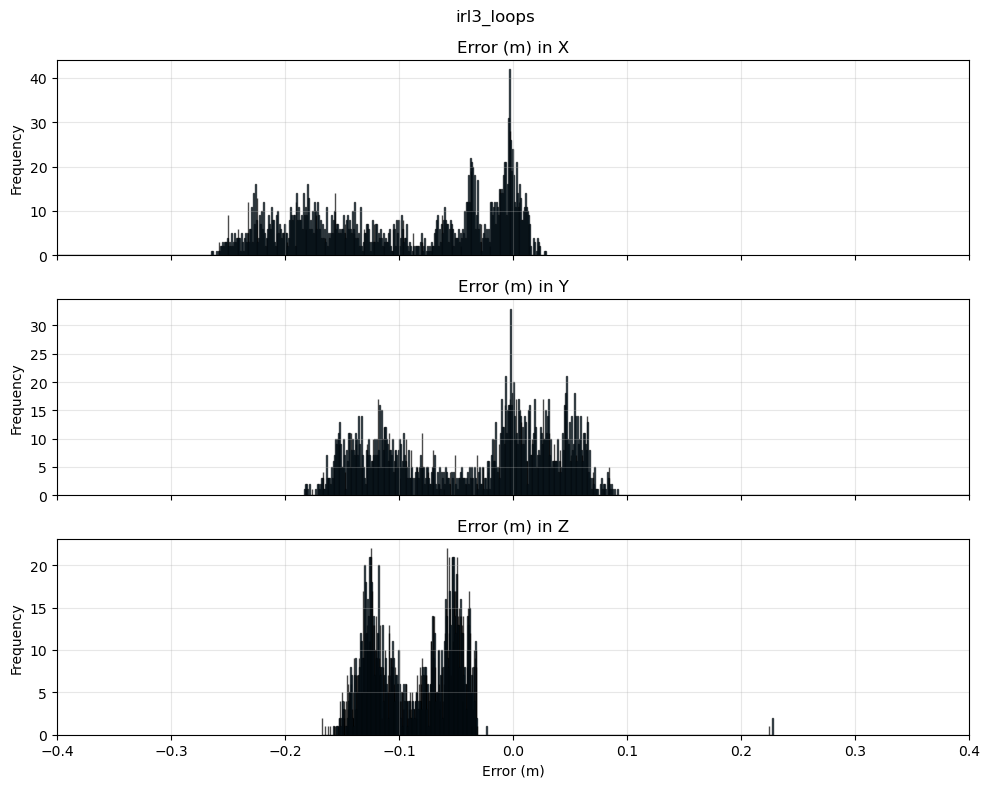

In [43]:


slam_poses, slam_ts, vicon_poses, vicon_ts = read_data('irl3_loops')
translation_errors = get_positional_errors(slam_poses, slam_ts, vicon_poses, vicon_ts)
plot_translational_errors(translation_errors, 'irl3_loops')



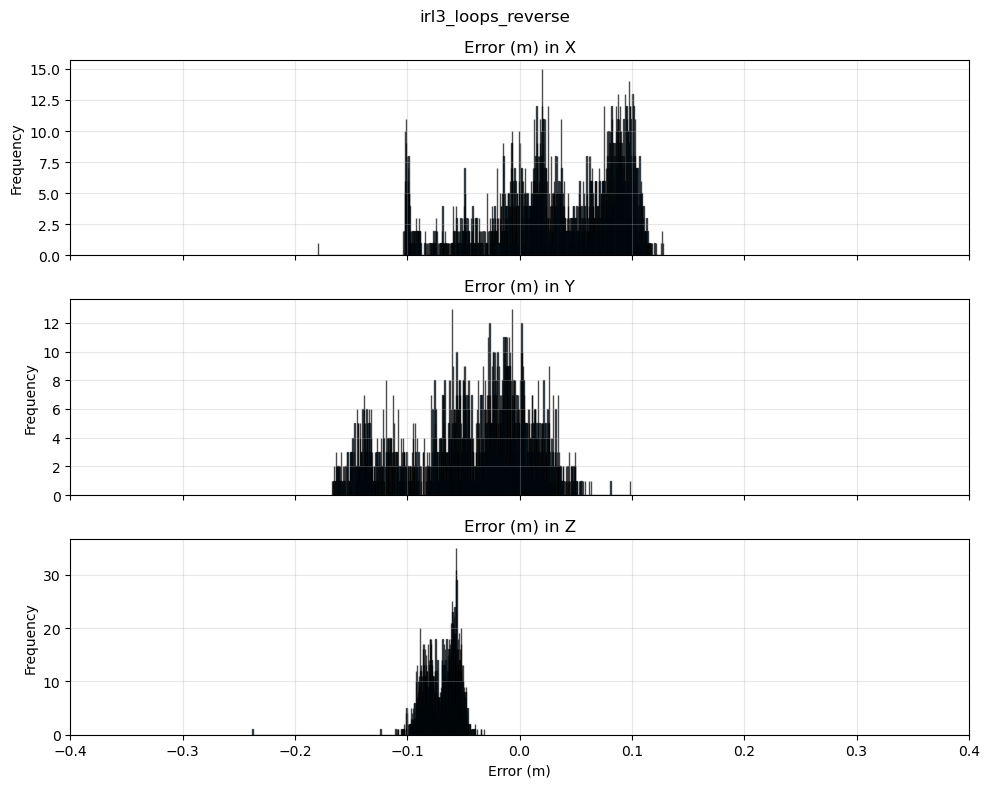

In [44]:
slam_poses, slam_ts, vicon_poses, vicon_ts = read_data('irl3_loops_reverse')
translation_errors = get_positional_errors(slam_poses, slam_ts, vicon_poses, vicon_ts)
plot_translational_errors(translation_errors, 'irl3_loops_reverse')